In [2]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import rasterio
from torch.nn import AvgPool2d
import torch

(140, 326)


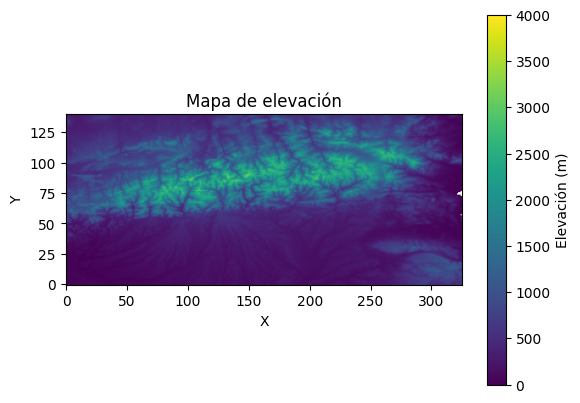

In [3]:
# Cargamos el archivo y lo leemos
with rasterio.open('mapa1.tif') as src:
    grid = src.read(1)
    nodata = src.nodata

# limpiar nodata
grid = np.where(grid == nodata, np.nan, grid)
grid = np.nan_to_num(grid, nan=1e6, posinf=1e6, neginf=-1e6)


# Tensor para el pooling
gtensor = torch.tensor(grid, dtype=torch.float32)
# añadir dimensiones necesarias para la funcion
gtensor = gtensor.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

# Para reducir el coste hacemos un average pooling de los datos del terreno
avp = AvgPool2d(kernel_size=16)
gridm = avp(gtensor)

# Devolvemos a numpy array en las dimensiones adecuadas
gridm = torch.Tensor.numpy(gridm.squeeze()) 



# máscara de agua
agua = gridm <= 0
elevacion = np.ma.masked_where(agua, gridm)

print(np.shape(elevacion))

fig, ax = plt.subplots()
im = ax.imshow(elevacion, cmap='viridis' , origin="lower", vmin=0, vmax=4000)
fig.colorbar(im, label="Elevación (m)")

ax.set_title("Mapa de elevación")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [4]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from scipy.interpolate import RegularGridInterpolator


class ParticleContEnv(gym.Env):

    def __init__(self, grid, max_steps=1000, goal_radius=1.0, step_size=1.0, render_mode=None):
        super().__init__()

        self.grid = (grid - grid.min()) / (grid.max() - grid.min())
        self.H, self.W = self.grid.shape

        self.max_steps   = max_steps
        self.goal_radius = goal_radius
        self.step_size   = step_size
        self.render_mode = render_mode

        # Interpoladores bilineales para V y gradiente
        rows = np.arange(self.H)
        cols = np.arange(self.W)

        self._V_interp = RegularGridInterpolator(
            (rows, cols), self.grid, method="linear", bounds_error=False, fill_value=1.0
        )

        gi, gj = np.gradient(self.grid)
        grad_mag = np.sqrt(gi**2 + gj**2)
        self._G_interp = RegularGridInterpolator(
            (rows, cols), grad_mag, method="linear", bounds_error=False, fill_value=0.0
        )

        # Acción continua: ángulo en [-π, π]
        # Acción: ángulo θ ∈ [-π, π]
        self.action_space = spaces.Box(
            low  = np.array([-np.pi], dtype=np.float32),
            high = np.array([ np.pi], dtype=np.float32),
            dtype=np.float32
        )

        # Observación: [i, j, goal_i, goal_j] normalizados en [0, 1]
        self.observation_space = spaces.Box(
            low=np.zeros(4, dtype=np.float32),
            high=np.ones(4, dtype=np.float32),
            dtype=np.float32
        )

    # ---------- helpers ----------

    def _query(self, i, j):
        pt = np.array([[i, j]])
        V = float(self._V_interp(pt)[0])
        G = float(self._G_interp(pt)[0])
        return V, G

    def _obs(self):
        return np.array([
            self.i      / (self.H - 1),
            self.j      / (self.W - 1),
            self.goal_i / (self.H - 1),
            self.goal_j / (self.W - 1),
        ], dtype=np.float32)

    def _clip(self, i, j):
        return (
            float(np.clip(i, 0, self.H - 1)),
            float(np.clip(j, 0, self.W - 1)),
        )

    # ---------- gym API ----------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.i      = float(self.np_random.uniform(0, self.H - 1))
        self.j      = float(self.np_random.uniform(0, self.W - 1))
        self.goal_i = float(self.np_random.uniform(0, self.H - 1))
        self.goal_j = float(self.np_random.uniform(0, self.W - 1))
        self.steps  = 0
        return self._obs(), {}

    def step(self, action):
        theta = float(action[0])
        prev_i, prev_j = self.i, self.j

        self.i, self.j = self._clip(
            self.i + self.step_size * np.sin(theta),
            self.j + self.step_size * np.cos(theta),
        )
        self.steps += 1

        prev_dist = np.linalg.norm([self.goal_i - prev_i, self.goal_j - prev_j])
        dist      = np.linalg.norm([self.goal_i - self.i,  self.goal_j - self.j])

        V, G = self._query(self.i, self.j)

        # Alineación: coseno entre dirección de movimiento y dirección al goal
        move_vec = np.array([self.i - prev_i, self.j - prev_j])
        goal_vec = np.array([self.goal_i - prev_i, self.goal_j - prev_j])
        norm_g   = np.linalg.norm(goal_vec)
        alignment = float(np.dot(move_vec, goal_vec) / (self.step_size * norm_g)) if norm_g > 1e-6 else 0.0

        reward = (
            3.0 * (prev_dist - dist)   # progreso
        + 1.0 * alignment            # alineación [-1, 1]
        - 2.0 * V                    # potencial
        - 1.0 * G                    # gradiente
        - 0.01                       # coste temporal
        )

        terminated = dist < self.goal_radius
        if terminated:
            reward += 20.0

        truncated = self.steps >= self.max_steps
        return self._obs(), reward, terminated, truncated, {"dist": dist, "V": V}

In [8]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv

# ---- entorno ----
def make_env():
    return ParticleContEnv(elevacion)

env = DummyVecEnv([make_env])


# ---- ruido (MUY IMPORTANTE en DDPG) ----
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.2 * np.ones(n_actions)
)

# ---- modelo ----
model = DDPG(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    action_noise=action_noise,
    train_freq=(1, "step"),
    verbose=1,
)

# ---- entrenamiento ----
model.learn(total_timesteps=20_000)

# ---- guardar ----
model.save("DDPG_map")

C:\Users\nol4n\AppData\Local\Temp\ipykernel_24928\725597000.py:29: RuntimeWarning: invalid value encountered in sqrt
  grad_mag = np.sqrt(gi**2 + gj**2)


Using cuda device


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

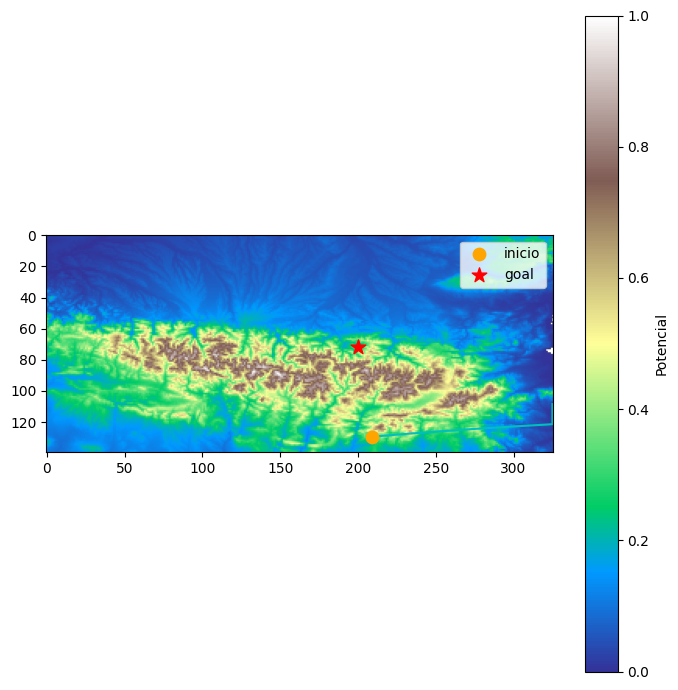

In [ ]:
def plot_trajectory(env, model, max_steps=1000):
    obs, _ = env.reset()
    traj = [(env.i, env.j)]

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        traj.append((env.i, env.j))
        if terminated or truncated:
            break

    traj = np.array(traj)

    plt.figure(figsize=(7, 7))
    plt.imshow(env.grid, cmap="terrain", origin="upper")
    plt.colorbar(label="Potencial")
    plt.plot(traj[:, 1], traj[:, 0], "c-", linewidth=1.5)
    plt.scatter(traj[0, 1],    traj[0, 0],    c="orange", s=80, zorder=5, label="inicio")
    plt.scatter(env.goal_j,    env.goal_i,    c="red", s=120, marker="*", zorder=5, label="goal")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_trajectory(env, model)